In [4]:
import os
print(os.getcwd())

d:\Data-Analysis-Project


In [5]:
import os
print("CURRENT FOLDER:", os.getcwd())
print("FILES HERE:", os.listdir())

CURRENT FOLDER: d:\Data-Analysis-Project
FILES HERE: ['analysis.ipynb', 'data.csv', 'README.md', 'titanic', 'titanic_cleaned.csv']


In [6]:
import os
print(os.listdir(r"D:\DATA-ANALYSIS-PROJECT\titanic"))

['gender_submission.csv', 'test.csv', 'train.csv']


In [ ]:
import pandas as pd

df = pd.read_csv("titanic/train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:

import pandas as pd
import numpy as np


df = pd.read_csv(r"titanic/train.csv")   

print("=== RAW DATA OVERVIEW ===")
print(f"Shape: {df.shape}")                     
print("\nColumns:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nFirst 5 rows:")
display(df.head())

=== RAW DATA OVERVIEW ===
Shape: (891, 12)

Columns:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Data types:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
# -------------------------------------------------
# 2️⃣ Clean the dataset
# -------------------------------------------------
df_clean = df.copy()   # work on a copy to keep raw data intact

# 3.1 Drop columns that are IDs or too noisy
cols_to_drop = ['PassengerId', 'Ticket', 'Cabin', 'Name']
df_clean.drop(columns=cols_to_drop, inplace=True)
# Reason: PassengerId & Ticket add no predictive signal.
# Cabin is >75% missing – extracting deck would be noisy.
# Name will be replaced by a more informative Title feature.

# 3.2 Extract Title from Name (useful surrogate)
# We need the original Name column for this step, so we re‑extract it:
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
# Map rare titles to a common group
title_map = {
    'Mr': 'Mr', 'Miss': 'Miss', 'Mrs': 'Mrs', 'Master': 'Master',
    'Dr': 'Officer', 'Rev': 'Officer', 'Col': 'Officer', 'Major': 'Officer',
    'Capt': 'Officer', 'Jonkheer': 'Royalty', 'Don': 'Royalty',
    'Sir': 'Royalty', 'Lady': 'Royalty', 'Countess': 'Royalty',
    'Dona': 'Royalty', 'Ms': 'Miss', 'Mme': 'Mrs', 'Mlle': 'Miss'
}
df['Title'] = df['Title'].map(title_map).fillna('Rare')
# Add Title to cleaned set and drop the raw Name column (already dropped)
df_clean['Title'] = df['Title']

# 3.3 Fix data types
cat_cols = ['Pclass', 'Sex', 'Embarked', 'Title']
df_clean[cat_cols] = df_clean[cat_cols].astype('category')
# Reason: reduces memory, signals to algorithms that these are nominal/ordinal.

# 3.4 Handle missing values
# Age – median per Sex & Pclass (more granular than global median)
df_clean['Age'] = df_clean.groupby(['Sex', 'Pclass'])['Age'].transform(
    lambda x: x.fillna(x.median())
)
# Embarked – mode (most common port)
df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])
# Fare – if any missing (rare), fill with median of its Pclass
df_clean['Fare'] = df_clean.groupby('Pclass')['Fare'].transform(
    lambda x: x.fillna(x.median())
)

# 3.5 Optional feature engineering (helps EDA & modeling)
df_clean['FamilySize'] = df_clean['SibSp'] + df_clean['Parch'] + 1
df_clean['IsAlone'] = (df_clean['FamilySize'] == 1).astype(int)

# 3.6 Final check
print("\n=== CLEANED DATA OVERVIEW ===")
print(f"Shape: {df_clean.shape}")
print("\nData types:")
print(df_clean.dtypes)
print("\nMissing values after cleaning:")
print(df_clean.isnull().sum())
print("\nFirst 5 rows:")
display(df_clean.head())


=== CLEANED DATA OVERVIEW ===
Shape: (891, 11)

Data types:
Survived         int64
Pclass        category
Sex           category
Age            float64
SibSp            int64
Parch            int64
Fare           float64
Embarked      category
Title         category
FamilySize       int64
IsAlone          int64
dtype: object

Missing values after cleaning:
Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked      0
Title         0
FamilySize    0
IsAlone       0
dtype: int64

First 5 rows:


<>:15: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<>:15: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_12692\1851255074.py:15: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,FamilySize,IsAlone
0,0,3,male,22.0,1,0,7.2500,S,Mr,2,0
1,1,1,female,38.0,1,0,71.2833,C,Mrs,2,0
2,1,3,female,26.0,0,0,7.9250,S,Miss,1,1
3,1,1,female,35.0,1,0,53.1000,S,Mrs,2,0
4,0,3,male,35.0,0,0,8.0500,S,Mr,1,1


Figure saved to: titanic_graphs.png


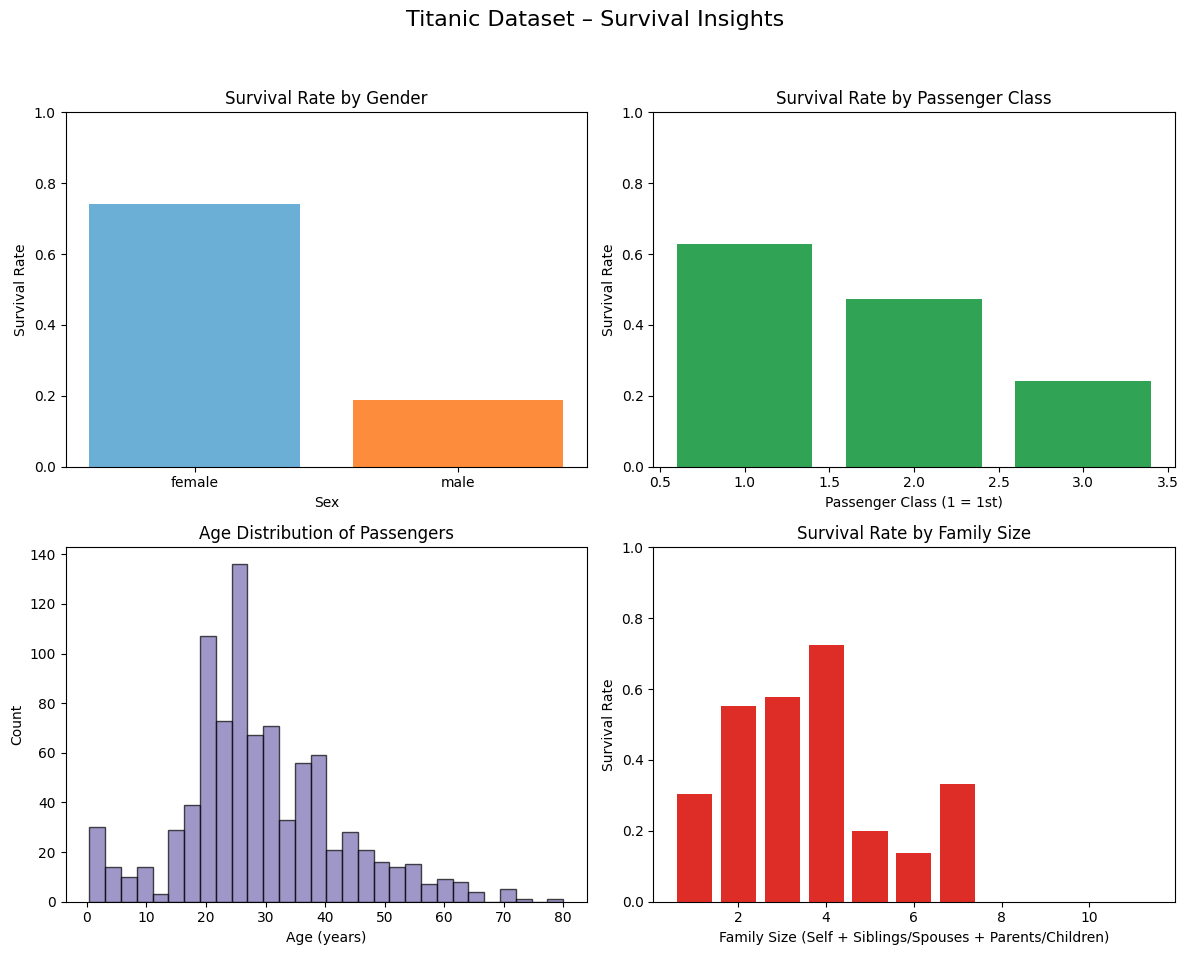

In [11]:
# -------------------------------------------------
# Visualise Titanic survival patterns (Matplotlib)
# -------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np

# Work on a copy to avoid accidental modifications
data = df_clean.copy()

# Helper: compute survival rate for a categorical column
def survival_rate(group_col):
    """Return proportion of survivors (1) per unique value of group_col."""
    return data.groupby(group_col)['Survived'].mean()

# ---- Metrics for the four plots ----
surv_by_sex   = survival_rate('Sex')
surv_by_class = survival_rate('Pclass')
ages          = data['Age'].dropna()               # cleaned data has no missing Age
surv_by_famsize = survival_rate('FamilySize')

# ---- Create a 2x2 grid of subplots ----
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Titanic Dataset – Survival Insights', fontsize=16, y=0.98)

# 1. Survival by gender
axes[0, 0].bar(surv_by_sex.index, surv_by_sex.values,
               color=['#6baed6', '#fd8d3c'])
axes[0, 0].set_title('Survival Rate by Gender')
axes[0, 0].set_xlabel('Sex')
axes[0, 0].set_ylabel('Survival Rate')
axes[0, 0].set_ylim(0, 1)

# 2. Survival by passenger class
axes[0, 1].bar(surv_by_class.index, surv_by_class.values,
               color='#31a354')
axes[0, 1].set_title('Survival Rate by Passenger Class')
axes[0, 1].set_xlabel('Passenger Class (1 = 1st)')
axes[0, 1].set_ylabel('Survival Rate')
axes[0, 1].set_ylim(0, 1)

# 3. Age distribution (all passengers)
axes[1, 0].hist(ages, bins=30, color='#756bb1',
                edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Age Distribution of Passengers')
axes[1, 0].set_xlabel('Age (years)')
axes[1, 0].set_ylabel('Count')

# 4. Survival by family size
axes[1, 1].bar(surv_by_famsize.index, surv_by_famsize.values,
               color='#de2d26')
axes[1, 1].set_title('Survival Rate by Family Size')
axes[1, 1].set_xlabel('Family Size (Self + Siblings/Spouses + Parents/Children)')
axes[1, 1].set_ylabel('Survival Rate')
axes[1, 1].set_ylim(0, 1)

# Adjust layout to make room for the suptitle
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Save the figure
output_path = r"titanic_graphs.png"
fig.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"Figure saved to: {output_path}")

# Show the plot
plt.show()